<a href="https://colab.research.google.com/github/Dhanushiya-tech/Portfolio-sample/blob/main/Fashion_MNIST_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [23]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

In [24]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

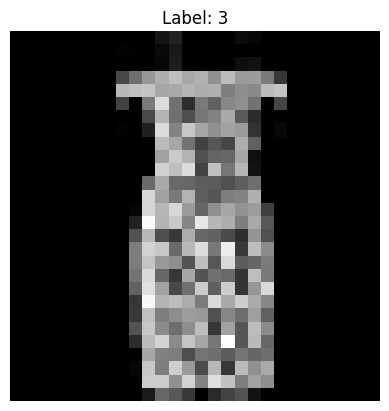

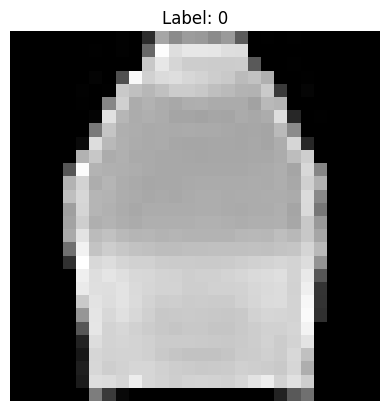

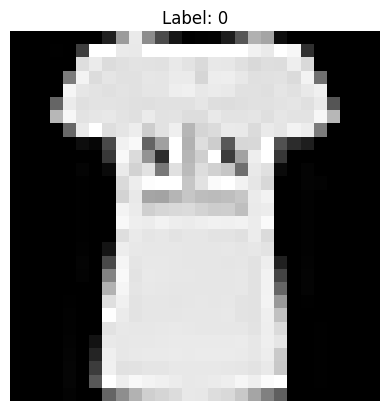

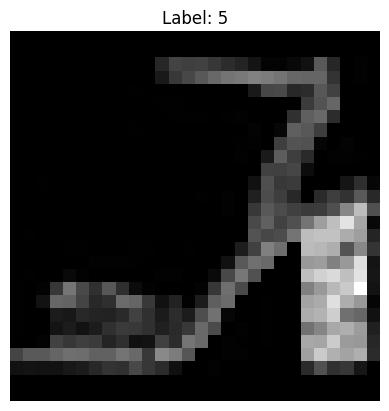

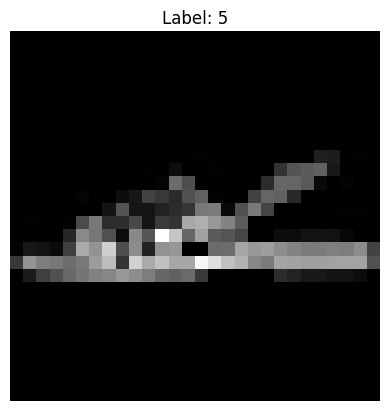

In [25]:
images, labels = next(iter(train_loader))

for i in range(5):
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Label: {labels[i].item()}")
    plt.axis('off')
    plt.show()

In [26]:
class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(28*28, 1)

    def forward(self, x):
        x = x.view(-1, 28*28)  # flatten image
        return self.linear(x)

model = LogisticRegressionModel()

In [27]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

In [28]:
epochs = 5

for epoch in range(epochs):
    total_loss = 0

    for images, labels in train_loader:
        images = images.view(-1, 28*28)
        labels = labels.float().view(-1,1)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: -50096794.0346
Epoch 2, Loss: -150413207.0469
Epoch 3, Loss: -250653920.3594
Epoch 4, Loss: -350859685.7656
Epoch 5, Loss: -451168611.1250


In [29]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.view(-1, 28*28)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int().squeeze()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print("Test Accuracy:", accuracy)

Test Accuracy: 0.1


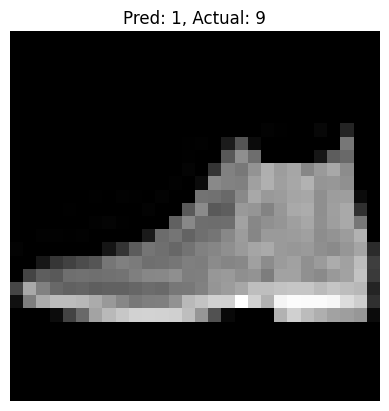

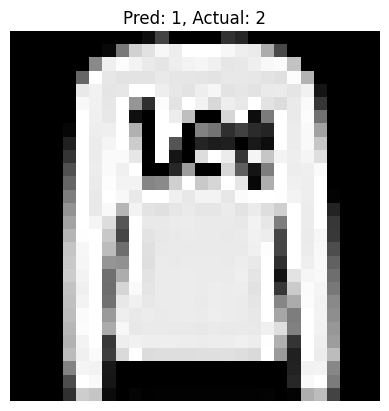

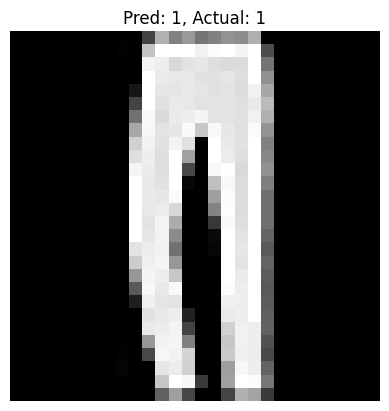

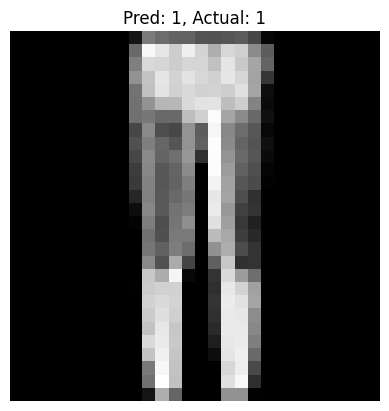

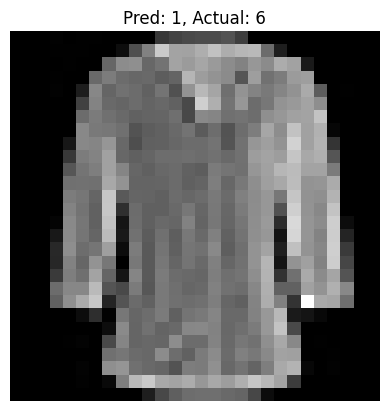

In [30]:
images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images.view(-1, 28*28))
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).int()

for i in range(5):
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}, Actual: {labels[i].item()}")
    plt.axis('off')
    plt.show()